# Offline vs cloud LLM tutoring — latency, cost and teaching quality

Everything below is **recomputed from raw per-turn transcripts**, not from
copied figures. Change a board, re-run the notebook, and every table and chart
follows.

## What the data is

Ten arms over two subject boards of 34 scenarios each, all on the same tutor
build and the same simulated students:

| tier | arms |
|---|---|
| on-device (RTX 3090, 24 GB) | `qwen3-4B`, `qwen3.8-27B` |
| cloud API | `claude-opus-4-7`, `gemini-3.5-flash`, `gpt-5.4-mini` |

Raw inputs, all in this repository:

- `multi_turn_results/<board>/trace/<arm>.jsonl` — one JSON object per tutor
  turn: latency, token buckets, tools called, the reply itself
- `multi_turn_results/<board>/<arm>.json` — per-scenario pass/fail
- `manual_grades/manual_grades_3runs_169.json` — 169 human verdicts across 8
  pedagogical dimensions
- `sweep_rtx3090_turnmode.log` — GPU concurrency sweep

## A caution before the numbers

`passed` in the board files counts **deterministic assertions only** — the
session completed, tools fired, grading resolved. It is not a measure of
teaching. Every arm ran with `EVAL_SKIP_RUBRIC=1`, so the quality signal comes
from the human grades in §4 and nowhere else.

In [1]:
import json, pathlib, statistics, collections, sys
import matplotlib.pyplot as plt
# No Agg backend here: this notebook is meant to be READ, so charts must render
# in the page for anyone opening it on GitHub or nbviewer without running it.
# Each figure is also written to figures/ for the paper.
import pandas as pd

ROOT = pathlib.Path.cwd()
if ROOT.name == "offline_eval":
    ROOT = ROOT.parent
RES = ROOT / "offline_eval" / "multi_turn_results"
sys.path.insert(0, str(ROOT))

LOCAL, CLOUD, GREY = "#1b6ca8", "#c0562f", "#777777"
IS_LOCAL = lambda arm: arm.startswith("qwen")

BOARDS = {
    "geography": ["geo_4b_v2", "geo_27b_v2", "geo_cloud"],
    "maths":     ["math_4b_v2", "math_27b_v3", "math_cloud"],
}
print("repo root:", ROOT)
print("boards found:", {k: [b for b in v if (RES/b).exists()] for k, v in BOARDS.items()})

repo root: /Users/edwardamoah/Documents/GitHub/ai-tutor
boards found: {'geography': ['geo_4b_v2', 'geo_27b_v2', 'geo_cloud'], 'maths': ['math_4b_v2', 'math_27b_v3', 'math_cloud']}


## 1. Load the raw data

Two sources, because they record different things:

- **`trace/<arm>.jsonl`** — one object per tutor turn from the engine: token
  buckets, tools called, retries, the reply. This is where cost comes from.
- **`<arm>.json`** — the board, whose `transcript` array carries `latency_ms`
  per message. This is where latency comes from, and it is timed around the
  whole turn as the simulated student experienced it: both model calls plus
  the platform's grading and database work between them.

Reading latency off the trace would silently yield nothing — the field is not
there — so the two are loaded separately rather than assumed to be one table.

In [2]:
def load_turns():
    rows = []
    for subject, boards in BOARDS.items():
        for board in boards:
            for f in sorted((RES / board / "trace").glob("*.jsonl")):
                for line in open(f):
                    try: r = json.loads(line)
                    except Exception: continue
                    rows.append({
                        "subject": subject, "board": board, "arm": f.stem,
                        "session": r.get("session_id"),
                        "tok_in": r.get("tok_in", 0) or 0,
                        "tok_cached": r.get("tok_cached", 0) or 0,
                        "tok_write": r.get("tok_write", 0) or 0,
                        "placeholder": bool(r.get("placeholder")),
                        "retries": r.get("retries", 0) or 0,
                        "verdict": r.get("verdict"),
                        "reply": r.get("reply") or "",
                    })
    return pd.DataFrame(rows)

def load_latency():
    # Tutor-message latencies, read from the board transcripts.
    rows = []
    for subject, boards in BOARDS.items():
        for board in boards:
            for f in sorted((RES / board).glob("*.json")):
                if f.name.startswith("partial_"):     # resume checkpoints
                    continue
                d = json.load(open(f))
                for res in d.get("results", []):
                    for t in res.get("transcript", []):
                        if t.get("latency_ms") is None:
                            continue
                        rows.append({"subject": subject, "board": board,
                                     "arm": f.stem, "role": t.get("role"),
                                     "sec": t["latency_ms"] / 1000,
                                     "scenario": res.get("scenario_id")})
    return pd.DataFrame(rows)

turns = load_turns()
msgs = load_latency()
print(f"{len(turns):,} traced turns across {turns.arm.nunique()} arms")
print(f"{len(msgs):,} timed messages "
      f"({(msgs.role=='tutor').sum():,} tutor, {(msgs.role=='student').sum():,} student)")
turns.groupby(["subject", "arm"]).agg(
    turns=("session", "size"), sessions=("session", "nunique"),
    placeholders=("placeholder", "sum"), retries=("retries", "sum"))

4,781 traced turns across 5 arms
9,216 timed messages (4,778 tutor, 4,438 student)


turns  sessions  placeholders  retries
subject   arm                                                         
geography claude-opus-4-7         314        34             0        0
          gemini-3.5-flash        310        34             0        0
          gpt-5.4-mini            295        34             0        0
          qwen3-4b-jetson         313        34             0        9
          qwen3.8-27b-instruct    294        34             0        0
maths     claude-opus-4-7         677        34             0        0
          gemini-3.5-flash        666        35             0        0
          gpt-5.4-mini            636        34             0        0
          qwen3-4b-jetson         635        34             0        0
          qwen3.8-27b-instruct    641        34             0        0

**Zero placeholders and zero retries everywhere** is the first thing to check.
A placeholder means a turn fell back to a canned reply after a failed call; any
non-zero count would mean the latency and quality numbers are measuring a
degraded system rather than the real one.

## 2. Latency

The number a student actually waits for one tutor reply.

In [3]:
# Tutor messages only: the student side is the simulator, not the system
# under test, and including it would dilute the number a real student waits.
TUTOR_ROLE = "tutor"      # transcript roles are tutor/student
lat = (msgs[msgs.role == TUTOR_ROLE]
            .groupby(["subject", "arm"])["sec"]
            .agg(turns="size", p50="median",
                 p95=lambda s: s.quantile(0.95), max="max")
            .round(2).reset_index())
lat_wide = lat.pivot(index="arm", columns="subject",
                     values=["p50", "p95"]).sort_values(("p50", "geography"))
lat_wide

p50              p95       
subject              geography  maths geography  maths
arm                                                   
gpt-5.4-mini              1.65   1.50      3.13   3.54
claude-opus-4-7           4.27   3.81      6.34   5.80
qwen3-4b-jetson           5.09   7.46      8.55  26.00
gemini-3.5-flash         10.55  15.75     17.16  33.51
qwen3.8-27b-instruct     19.62  14.86     26.36  19.65

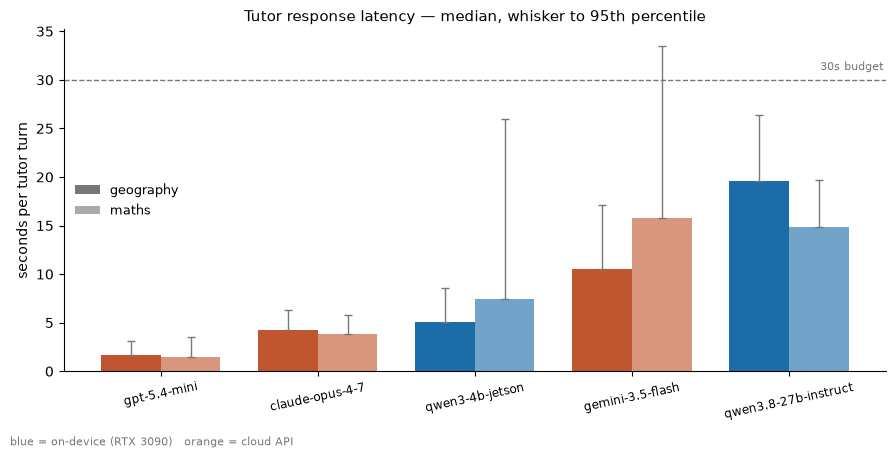

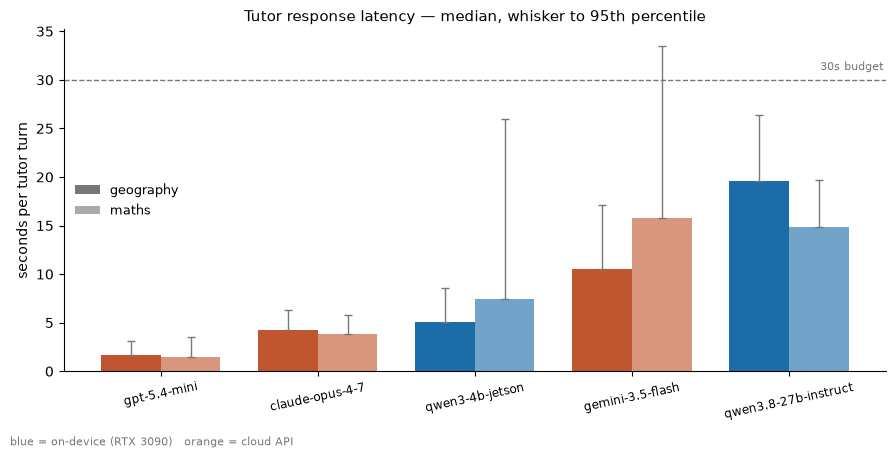

In [4]:
arms = list(lat_wide.index)
fig, ax = plt.subplots(figsize=(9, 4.6))
w = 0.38
for i, (off, subj, alpha) in enumerate(((-w/2, "geography", 1.0), (w/2, "maths", 0.62))):
    p50 = [lat_wide.loc[a, ("p50", subj)] for a in arms]
    p95 = [lat_wide.loc[a, ("p95", subj)] for a in arms]
    ax.bar([x + off for x in range(len(arms))], p50, w,
           yerr=[[0]*len(p50), [b - a for a, b in zip(p50, p95)]],
           color=[LOCAL if IS_LOCAL(a) else CLOUD for a in arms],
           alpha=alpha, capsize=3, error_kw={"ecolor": GREY, "lw": 1})
from matplotlib.patches import Patch
# Colour encodes local-vs-cloud, opacity encodes subject. Coloured legend
# swatches would claim colour means subject, so the legend is neutral grey.
ax.legend(handles=[Patch(facecolor=GREY, alpha=1.0, label="geography"),
                   Patch(facecolor=GREY, alpha=0.62, label="maths")],
          fontsize=9, frameon=False)
ax.set_xticks(range(len(arms))); ax.set_xticklabels(arms, fontsize=8.5, rotation=12)
ax.set_ylabel("seconds per tutor turn")
ax.set_title("Tutor response latency — median, whisker to 95th percentile", fontsize=11)
ax.axhline(30, ls="--", lw=1, color=GREY)
ax.text(len(arms)-0.4, 31, "30s budget", fontsize=8, color=GREY, ha="right")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.text(0.01, 0.02, "blue = on-device (RTX 3090)   orange = cloud API", fontsize=8, color=GREY)
fig.tight_layout(rect=(0, 0.04, 1, 1)); fig.savefig("figures/fig1_latency.png", dpi=200)
fig

**The local 4B is not the slow option.** It beats Gemini Flash on both subjects
and sits close to Opus. The slowest cloud arm is slower than the fastest local
one — which is the opposite of the usual assumption about on-device inference.

## 3. Cost

### 3.1 Metered cloud spend, from the token buckets

The three buckets are **disjoint**: a provider's `input_tokens` excludes cached
tokens, so the prompt's true size is fresh + cached + written. Treating the
first as the total makes cache reads look larger than the input and prices a
run negative.

In [5]:
PRICES = {"claude-opus-4-7": 5.00, "gemini-3.5-flash": 0.30, "gpt-5.4-mini": 0.25}
CACHE_READ, CACHE_WRITE = 0.10, 1.25       # multiples of the input rate

cloud = turns[turns.arm.isin(PRICES)]
cost = (cloud.groupby(["subject", "arm"])
        .agg(fresh=("tok_in", "sum"), cached=("tok_cached", "sum"),
             written=("tok_write", "sum"), sessions=("session", "nunique"))
        .reset_index())
rate = cost.arm.map(PRICES)
cost["hit_%"] = (100 * cost.cached / (cost.fresh + cost.cached + cost.written)).round(0)
cost["cost_usd"] = ((cost.fresh*rate + cost.cached*rate*CACHE_READ
                   + cost.written*rate*CACHE_WRITE) / 1e6).round(2)
cost["uncached_usd"] = ((cost.fresh + cost.cached + cost.written) * rate / 1e6).round(2)
cost["usd_per_session"] = (cost.cost_usd / cost.sessions).round(4)
display(cost)
print(f"total metered spend  ${cost.cost_usd.sum():.2f}"
      f"   uncached would be ${cost.uncached_usd.sum():.2f}"
      f"   caching saved ${cost.uncached_usd.sum()-cost.cost_usd.sum():.2f}")

,subject,arm,fresh,cached,written,sessions,hit_%,cost_usd,uncached_usd,usd_per_session
0,geography,claude-opus-4-7,1504857,4124127,415837,34,68.0,12.19,30.22,0.3585
1,geography,gemini-3.5-flash,5557243,244212,0,34,4.0,1.67,1.74,0.0491
2,geography,gpt-5.4-mini,3613357,2209408,0,34,38.0,0.96,1.46,0.0282
3,maths,claude-opus-4-7,2495266,7747380,389298,34,73.0,18.78,53.16,0.5524
4,maths,gemini-3.5-flash,10615578,1739055,0,35,14.0,3.24,3.71,0.0926
5,maths,gpt-5.4-mini,6651701,4237184,0,34,39.0,1.77,2.72,0.0521


total metered spend  $38.61   uncached would be $93.01   caching saved $54.40


Note **Gemini's cache barely engages** (single-digit hit rate) against Opus's
~70%. On a workload that re-sends the same static prefix every turn, reads
should dominate after the first turn of a session. It costs little at Flash
prices, but the same behaviour on a heavier tier would re-bill the whole prefix
every turn.

### 3.2 Cost per student per year

The tiers are priced in different units, and the comparison only means
something once both are per student per year.

- **Cloud is metered** — every session bills tokens; the school pays again
  every year, forever.
- **Offline is capital** — one card bought once, amortised over the roll and
  its life. Cost per student *falls* as the school grows.

`SESSIONS_PER_YEAR` scales the cloud column and leaves the GPU column
untouched, so it decides the comparison on its own. **Change it first.**

In [6]:
SESSIONS_PER_YEAR = 200      # 5/week x 40 weeks; the pilot expects 5-10/week
GPU_CAPITAL, GPU_WATTS, KWH = 2500.0, 350.0, 0.20
HOURS_DAY, SCHOOL_DAYS = 6, 190
POWER_YR = GPU_WATTS/1000 * HOURS_DAY * SCHOOL_DAYS * KWH

per_session = cost.groupby("arm")["usd_per_session"].mean()   # mixed timetable
cloud_year = (per_session * SESSIONS_PER_YEAR).round(2)

def gpu_year(students, years):
    return (GPU_CAPITAL/years + POWER_YR) / students

rows = [{"option": f"{a} (cloud)", "$/student/yr": v} for a, v in cloud_year.items()]
for st in (150, 300):
    for yr in (1, 2):
        rows.append({"option": f"RTX 3090 — {st} students, {yr}y life",
                     "$/student/yr": round(gpu_year(st, yr), 2)})
display(pd.DataFrame(rows).sort_values("$/student/yr").reset_index(drop=True))
print(f"electricity is ${POWER_YR:.0f}/yr — "
      f"{100*POWER_YR/(GPU_CAPITAL/2+POWER_YR):.0f}% of a 2-year-life total")

,option,$/student/yr
0,"RTX 3090 — 300 students, 2y life",4.43
1,gpt-5.4-mini (cloud),8.03
2,"RTX 3090 — 300 students, 1y life",8.60
3,"RTX 3090 — 150 students, 2y life",8.87
4,gemini-3.5-flash (cloud),14.17
5,"RTX 3090 — 150 students, 1y life",17.20
6,claude-opus-4-7 (cloud),91.09


electricity is $80/yr — 6% of a 2-year-life total


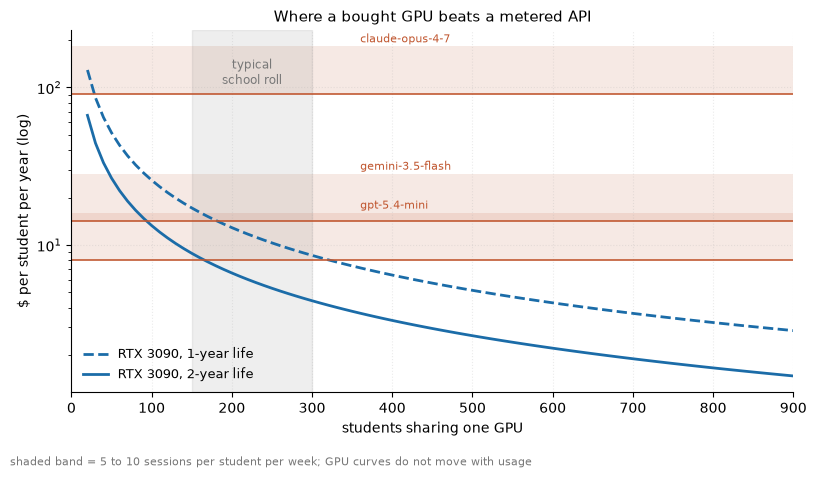

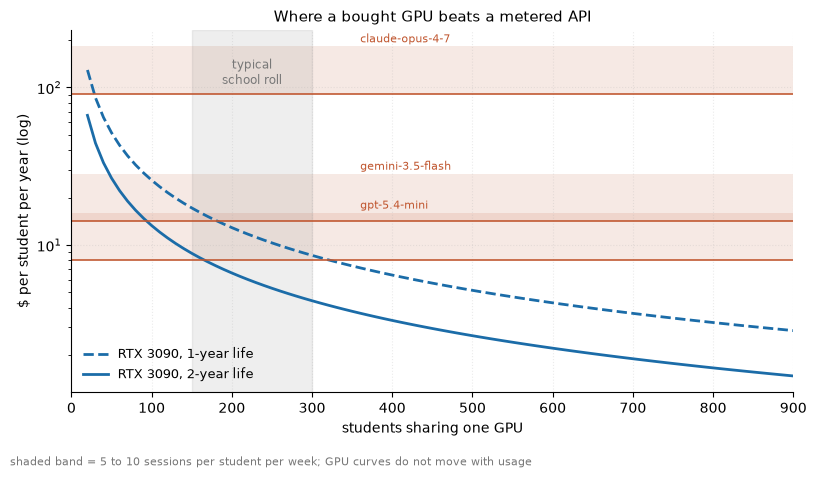

In [7]:
rolls = list(range(20, 901, 10))
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for years, ls in ((1, "--"), (2, "-")):
    ax.plot(rolls, [gpu_year(r, years) for r in rolls], ls, color=LOCAL, lw=2,
            label=f"RTX 3090, {years}-year life")
# A band, not a line: usage is the dominant uncertainty and moves cloud cost 2x
# across 5-10 sessions/week, while the GPU curves do not move at all.
for arm, ps in per_session.items():
    lo, hi = ps*200, ps*400
    ax.fill_between([0, 900], lo, hi, color=CLOUD, alpha=0.13, lw=0)
    ax.plot([0, 900], [lo, lo], color=CLOUD, lw=1.3, alpha=0.9)
    ax.text(360, hi*1.06, arm, fontsize=8, color=CLOUD, ha="left")
ax.axvspan(150, 300, color=GREY, alpha=0.12)
ax.text(225, ax.get_ylim()[1]*0.55, "typical\nschool roll", fontsize=8.5,
        color=GREY, ha="center")
ax.set_yscale("log"); ax.set_xlim(0, 900)
ax.set_xlabel("students sharing one GPU"); ax.set_ylabel("$ per student per year (log)")
ax.set_title("Where a bought GPU beats a metered API", fontsize=11)
ax.legend(fontsize=9, frameon=False, loc="lower left"); ax.grid(alpha=0.25, ls=":")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.text(0.01, 0.02, "shaded band = 5 to 10 sessions per student per week; "
         "GPU curves do not move with usage", fontsize=8, color=GREY)
fig.tight_layout(rect=(0, 0.05, 1, 1)); fig.savefig("figures/fig3_crossover.png", dpi=200)
fig

In [8]:
# Crossover: the roll at which the card becomes cheaper than each cloud tier.
cross = []
for arm, ps in per_session.items():
    row = {"cloud model": arm}
    for sess in (200, 400):
        for yr in (1, 2):
            row[f"{sess}/yr, {yr}y card"] = round((GPU_CAPITAL/yr + POWER_YR)/(ps*sess))
    cross.append(row)
pd.DataFrame(cross).set_index("cloud model")

,"200/yr, 1y card","200/yr, 2y card","400/yr, 1y card","400/yr, 2y card"
cloud model,,,,
claude-opus-4-7,28,15,14,7
gemini-3.5-flash,182,94,91,47
gpt-5.4-mini,321,166,161,83


**Below the crossover the cloud is genuinely cheaper** — the card is idle
capital. Above it the GPU wins and keeps winning, because the cloud bill
repeats every year while the card is already paid for.

At 5–10 sessions/week and a 150–300 roll the card beats every cloud tier with
one exception: a 150-student school replacing the card annually, against the
cheapest cloud model. At 2 sessions/week the answer flips — which is why usage
belongs in the paper as a stated assumption, not a hidden constant.

## 4. Teaching quality — 169 human grades

Graded in the viewer's Grade tab against the eight dimensions of
`ai_tutor/apps/benchmark/pedagogy.py`. A session passes only if **every
applicable dimension** sits at its desideratum — all-or-nothing, `n/a`
excluded rather than counted as failure. The pass rule here is the same Python
the dashboard uses, imported rather than reimplemented.

In [9]:
from ai_tutor.apps.benchmark import pedagogy as P

gfile = ROOT / "offline_eval" / "manual_grades" / "manual_grades_3runs_169.json"
G = json.load(open(gfile))
DIMS = G["dimensions"]
# Incomplete gradings are excluded entirely: an unanswered dimension is not a
# "no", and scoring it as one would invent failures.
complete = {k: v for k, v in G["verdicts"].items() if len(v.get("d", {})) == len(DIMS)}
print(f"{len(G['verdicts'])} verdicts stored, {len(complete)} complete, "
      f"{sum(1 for v in complete.values() if v.get('peeked'))} peeked")

qual = collections.defaultdict(lambda: [0, 0])
for k, v in complete.items():
    arm = k.split("|")[1]
    qual[arm][0] += 1
    qual[arm][1] += bool(P.session_passes(v["d"]))
quality = pd.DataFrame([{"arm": a, "graded": n, "passed": p,
                         "pass_rate_%": round(100*p/n, 1)}
                        for a, (n, p) in qual.items()]).sort_values(
                        "pass_rate_%", ascending=False).reset_index(drop=True)
quality

170 verdicts stored, 169 complete, 0 peeked


,arm,graded,passed,pass_rate_%
0,claude-opus-4-7,34,34,100.0
1,qwen3.8-27b-instruct,34,33,97.1
2,gpt-5.4-mini,33,29,87.9
3,gemini-3.5-flash,34,24,70.6
4,qwen3-4b-jetson,34,23,67.6


In [10]:
DES = {d.key: d.desideratum for d in P.DIMENSIONS}
recs = []
for k, v in complete.items():
    arm = k.split("|")[1]
    for dim, val in v["d"].items():
        if val == "n/a":       # unscorable by the taxonomy, not a failure
            continue
        recs.append({"arm": arm, "dimension": dim, "fail": val != DES.get(dim)})
fails = (pd.DataFrame(recs).groupby(["dimension", "arm"])["fail"]
         .mean().mul(100).round(0).unstack(fill_value=0))
fails = fails.loc[fails.max(axis=1) > 0]      # hide dimensions nobody failed
display(fails)
print("dimensions omitted (every arm at 100%):",
      sorted(set(DES) - set(fails.index)))

arm,claude-opus-4-7,gemini-3.5-flash,gpt-5.4-mini,qwen3-4b-jetson,qwen3.8-27b-instruct
dimension,,,,,
actionability,0.0,0.0,0.0,15.0,0.0
coherence,0.0,6.0,0.0,0.0,3.0
providing_guidance,0.0,24.0,3.0,0.0,0.0
revealing_answer,0.0,3.0,9.0,32.0,0.0


dimensions omitted (every arm at 100%): ['human_likeness', 'mistake_identification', 'mistake_location', 'tutor_tone']


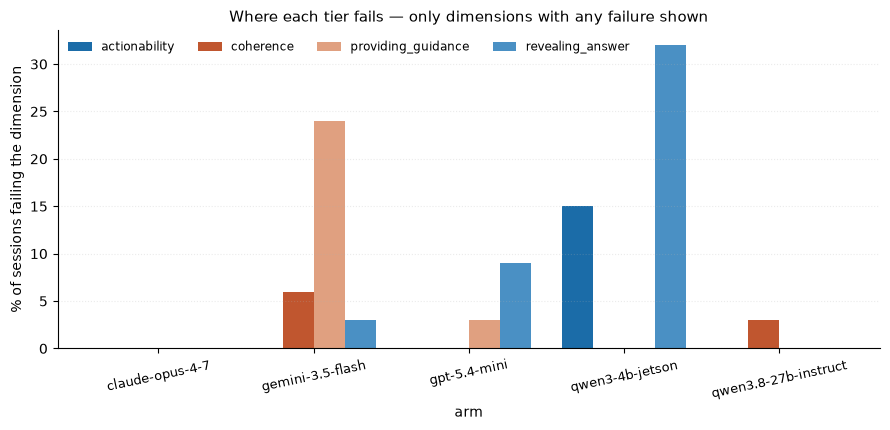

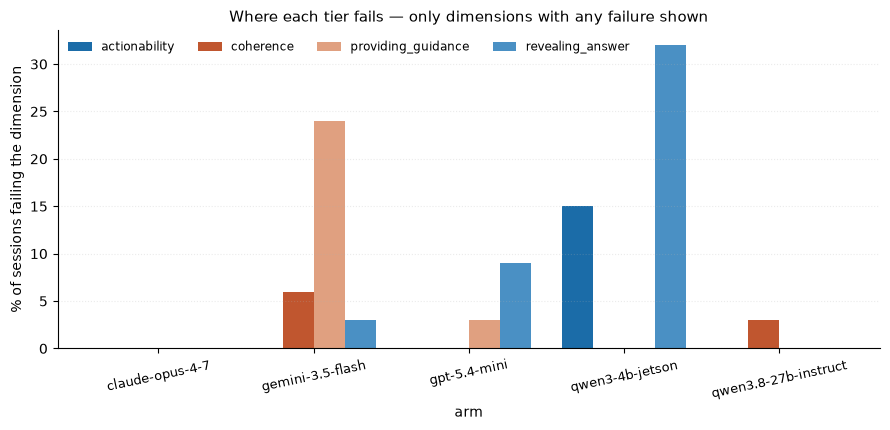

In [11]:
ax = fails.T.plot(kind="bar", figsize=(9, 4.4), width=0.8,
                  color=["#1b6ca8", "#c0562f", "#e0a080", "#4a90c4"])
ax.set_ylabel("% of sessions failing the dimension")
ax.set_title("Where each tier fails — only dimensions with any failure shown", fontsize=11)
ax.legend(fontsize=8.5, frameon=False, ncol=4, title=None)
ax.grid(axis="y", alpha=0.25, ls=":")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.xticks(rotation=12, fontsize=9); plt.tight_layout()
plt.savefig("figures/fig4_dimensions.png", dpi=200); plt.gcf()

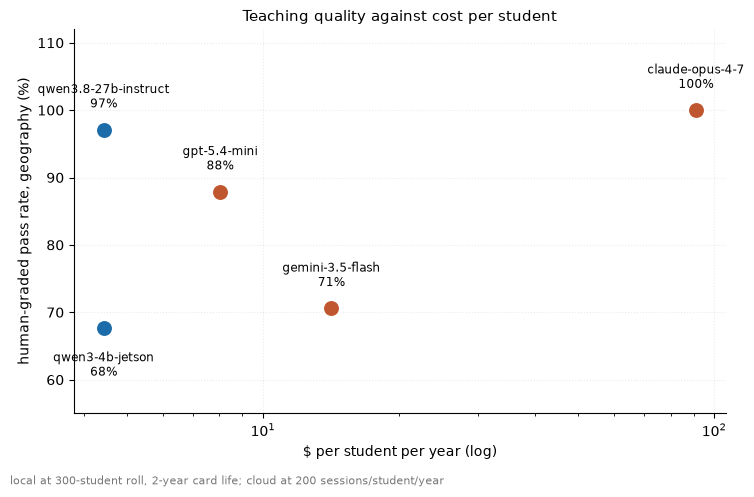

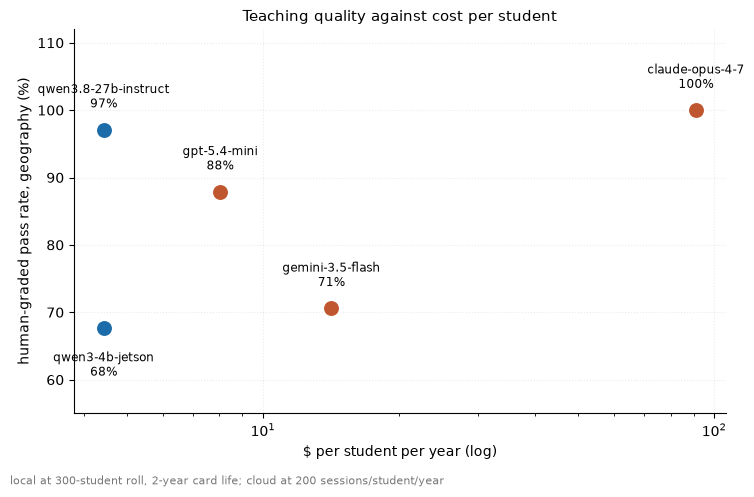

In [12]:
# Quality against cost — the trade-off in one view.
fig, ax = plt.subplots(figsize=(7.6, 5))
gpu_cost_2y_300 = gpu_year(300, 2)
placed = []
for _, r in quality.iterrows():
    arm = r["arm"]
    x = cloud_year.get(arm, gpu_cost_2y_300)
    col = LOCAL if IS_LOCAL(arm) else CLOUD
    ax.scatter(x, r["pass_rate_%"], s=150, color=col, zorder=3,
               edgecolor="white", lw=1.5)
    # Nudge labels apart: the two local arms share an x (one shared card).
    dy = -34 if (any(abs(x-px) < 1 and abs(r['pass_rate_%']-py) > 20
                     for px, py in placed) and r['pass_rate_%'] < 80) else 16
    ax.annotate(f"{arm}\n{r['pass_rate_%']:.0f}%", (x, r["pass_rate_%"]),
                textcoords="offset points", xytext=(0, dy), ha="center", fontsize=8.5)
    placed.append((x, r["pass_rate_%"]))
ax.set_xscale("log"); ax.set_xlabel("$ per student per year (log)")
ax.set_ylabel("human-graded pass rate, geography (%)")
ax.set_title("Teaching quality against cost per student", fontsize=11)
ax.set_ylim(55, 112); ax.grid(alpha=0.25, ls=":")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.text(0.01, 0.02, f"local at 300-student roll, 2-year card life; "
         f"cloud at {SESSIONS_PER_YEAR} sessions/student/year", fontsize=8, color=GREY)
fig.tight_layout(rect=(0, 0.04, 1, 1)); fig.savefig("figures/fig2_quality_vs_cost.png", dpi=200)
fig

## 5. Concurrency — how many students one card serves

From `sweep_rtx3090_turnmode.log`. Each level fires N simultaneous **whole
turns** (the short tool-picking call, then the full reply) and reports how
latency degrades. Requests beyond the server's slot count queue rather than
fail, so N can exceed the slots.

In [13]:
import re
_HDR = re.compile(r"^#+ (\S+) slots=(\d+)")
_ROW = re.compile(r"^\s*(\d+)\s+\d+\s+([\d.]+)s\s+([\d.]+)s")
sweep, key = [], None
for line in open(ROOT / "offline_eval" / "sweep_rtx3090_turnmode.log"):
    h = _HDR.match(line)
    if h: key = (h.group(1), int(h.group(2))); continue
    r = _ROW.match(line)
    if r and key:
        sweep.append({"model": key[0], "slots": key[1], "N": int(r.group(1)),
                      "turn_p50": float(r.group(2)), "turn_p95": float(r.group(3))})
sweep = pd.DataFrame(sweep)
display(sweep)

BUDGET = 30.0    # seconds a student will wait for one tutor turn
cap = (sweep[sweep.turn_p50 <= BUDGET].groupby("model")["N"].max()
       .rename(f"max concurrent @{BUDGET:.0f}s median").to_frame())
cap[f"@{BUDGET:.0f}s 95th pct"] = sweep[sweep.turn_p95 <= BUDGET].groupby("model")["N"].max()
cap

,model,slots,N,turn_p50,turn_p95
0,qwen3-4b-ctx8k,24,1,2.6,2.5
1,qwen3-4b-ctx8k,24,32,20.0,28.6
2,qwen3-4b-ctx8k,24,48,28.8,36.3
3,qwen3-4b-ctx8k,24,64,39.4,51.1
4,qwen3-4b-ctx8k,24,80,44.0,59.9
5,qwen3.8-27b-instruct,4,1,8.9,8.8
6,qwen3.8-27b-instruct,4,4,22.6,28.3
7,qwen3.8-27b-instruct,4,6,31.5,42.8
8,qwen3.8-27b-instruct,4,8,39.0,52.6
9,qwen3.8-27b-instruct,4,12,55.6,77.6


,max concurrent @30s median,@30s 95th pct
model,,
qwen3-4b-ctx8k,48,32
qwen3.8-27b-instruct,4,4


**This is the deployment decision.** The 27B teaches nearly as well as a
frontier model but serves a handful of students at once; the 4B serves an order
of magnitude more and reveals the answer far too often. Fixing the 4B's
revealing-answer behaviour is worth more than any model swap available here —
it is the only change that would give a full class frontier-adjacent tutoring
on one card.

## 6. Summary

| | |
|---|---|
| **Latency** | the local 4B beats two of three cloud arms; the 27B is the slowest local option |
| **Cost** | at 5–10 sessions/week the card beats every cloud tier at a 150–300 roll, bar one corner case |
| **Quality** | the local 27B reaches 97% against Opus's 100% — at a fraction of the cost |
| **Capacity** | but the 27B serves ~4 concurrent students; the 4B serves ~48 at 68% quality |

### What this does not establish

- **Geography only.** The maths grades are outstanding. The maths board also
  carries a content ceiling — two lessons hold fewer MCQs than a session needs,
  so sessions there hit the turn cap regardless of model. Discount those on
  every arm.
- **Assertions are not pedagogy.** The board `passed` column measures whether
  the machinery worked, nothing more.
- **Neither cost column is a full TCO.** The GPU side excludes the host
  machine, networking, physical security and teacher time; the cloud side
  excludes the internet connection an offline deployment exists to avoid
  needing.